# Forget vs Retain Distribution Analysis

This notebook reproduces the repo's forget/retain split and compares distribution distances for:

- class-wise forgetting
- IID random forgetting from the full training set

It reports:

- label-distribution divergence: total variation and Jensen-Shannon divergence
- feature-space divergence from a checkpoint: mean shift, linear MMD, Fr\u00e9chet distance
- forget-vs-retain separability AUC in feature space


In [13]:
from pathlib import Path
from types import SimpleNamespace
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import DataLoader

ROOT = Path.cwd()
if not (ROOT / "dataset.py").exists():
    ROOT = ROOT / "classification" / "classification_EU_RL"
ROOT = ROOT.resolve()
assert (ROOT / "dataset.py").exists(), f"Could not locate classification_EU_RL from {Path.cwd()}"

import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import utils

CONFIG = {
    "dataset": "cifar10",
    "arch": "resnet18",
    "data": str(ROOT / "datasets" / "cifar10"),
    "batch_size": 256,
    "workers": 0,
    "seed": 1,
    "train_seed": 1,
    "num_classes": 10,
    "imagenet_arch": False,
    "no_aug": True,
    "forget_mode": "iid_random",
    "comparison_modes": ["iid_random", "class"],
    "class_to_replace": 0,
    "num_indexes_to_replace": None,
    "forget_fraction": 0.10,
    "indexes_to_replace": None,
    "checkpoint": str(ROOT / "pretrained_models" / "resnet18" / "cifar10" / "model_SA_best.pth.tar"),
    "feature_max_samples": 4000,
    "permutation_trials": 200,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

pd.Series(CONFIG)

dataset                                                             cifar10
arch                                                               resnet18
data                      /home/yuen_chen/EUPMU-Efficient-Utility-Preser...
batch_size                                                              256
workers                                                                   0
seed                                                                      1
train_seed                                                                1
num_classes                                                              10
imagenet_arch                                                         False
no_aug                                                                 True
forget_mode                                                      iid_random
comparison_modes                                        [iid_random, class]
class_to_replace                                                          0
num_indexes_

In [14]:
def make_args(config, *, class_to_replace=None, num_indexes_to_replace=None, indexes_to_replace=None):
    return SimpleNamespace(
        dataset=config["dataset"],
        arch=config["arch"],
        data=config["data"],
        batch_size=config["batch_size"],
        workers=config["workers"],
        seed=config["seed"],
        train_seed=config["train_seed"],
        num_classes=config["num_classes"],
        imagenet_arch=config["imagenet_arch"],
        no_aug=config["no_aug"],
        class_to_replace=class_to_replace,
        num_indexes_to_replace=num_indexes_to_replace,
        indexes_to_replace=indexes_to_replace,
    )


def resolve_forget_selection(config, train_size, forget_mode=None):
    mode = config["forget_mode"] if forget_mode is None else forget_mode

    if mode == "class":
        return {
            "forget_mode": mode,
            "class_to_replace": config["class_to_replace"],
            "num_indexes_to_replace": config["num_indexes_to_replace"],
            "indexes_to_replace": config["indexes_to_replace"],
            "description": f"class-wise forget, class={config['class_to_replace']}",
        }

    if mode == "iid_random":
        if config["indexes_to_replace"] is not None:
            return {
                "forget_mode": mode,
                "class_to_replace": None,
                "num_indexes_to_replace": None,
                "indexes_to_replace": config["indexes_to_replace"],
                "description": f"IID random forget from explicit index list, n={len(config['indexes_to_replace'])}",
            }

        num_indexes = config["num_indexes_to_replace"]
        if num_indexes is None:
            num_indexes = int(round(config["forget_fraction"] * train_size))

        return {
            "forget_mode": mode,
            "class_to_replace": -1,
            "num_indexes_to_replace": num_indexes,
            "indexes_to_replace": None,
            "description": f"IID random forget, n={num_indexes} out of {train_size}",
        }

    raise ValueError(f"Unknown forget_mode: {mode}")


def replace_loader_dataset(dataset, batch_size, seed=1, shuffle=False):
    utils.setup_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        num_workers=0,
        pin_memory=True,
        shuffle=shuffle,
    )


def split_forget_retain(marked_loader, train_loader_full, args):
    forget_dataset = copy.deepcopy(marked_loader.dataset)

    if args.dataset == "svhn":
        try:
            marked = forget_dataset.targets < 0
        except AttributeError:
            marked = forget_dataset.labels < 0

        forget_dataset.data = forget_dataset.data[marked]
        try:
            forget_dataset.targets = -forget_dataset.targets[marked] - 1
        except AttributeError:
            forget_dataset.labels = -forget_dataset.labels[marked] - 1

        retain_dataset = copy.deepcopy(marked_loader.dataset)
        try:
            marked = retain_dataset.targets >= 0
        except AttributeError:
            marked = retain_dataset.labels >= 0
        retain_dataset.data = retain_dataset.data[marked]
        try:
            retain_dataset.targets = retain_dataset.targets[marked]
        except AttributeError:
            retain_dataset.labels = retain_dataset.labels[marked]
    else:
        try:
            marked = forget_dataset.targets < 0
            forget_dataset.data = forget_dataset.data[marked]
            forget_dataset.targets = -forget_dataset.targets[marked] - 1

            retain_dataset = copy.deepcopy(marked_loader.dataset)
            marked = retain_dataset.targets >= 0
            retain_dataset.data = retain_dataset.data[marked]
            retain_dataset.targets = retain_dataset.targets[marked]
        except Exception:
            marked = forget_dataset.targets < 0
            forget_dataset.imgs = forget_dataset.imgs[marked]
            forget_dataset.targets = -forget_dataset.targets[marked] - 1

            retain_dataset = copy.deepcopy(marked_loader.dataset)
            marked = retain_dataset.targets >= 0
            retain_dataset.imgs = retain_dataset.imgs[marked]
            retain_dataset.targets = retain_dataset.targets[marked]

    assert len(forget_dataset) + len(retain_dataset) == len(train_loader_full.dataset)

    forget_loader = replace_loader_dataset(forget_dataset, batch_size=args.batch_size, seed=args.seed, shuffle=False)
    retain_loader = replace_loader_dataset(retain_dataset, batch_size=args.batch_size, seed=args.seed, shuffle=False)
    return forget_dataset, retain_dataset, forget_loader, retain_loader


def get_targets(dataset):
    for name in ("targets", "labels", "_labels"):
        if hasattr(dataset, name):
            return np.asarray(getattr(dataset, name), dtype=np.int64)
    raise AttributeError("Dataset does not expose targets/labels/_labels")


def normalized_histogram(targets, num_classes):
    hist = np.bincount(targets, minlength=num_classes).astype(np.float64)
    return hist / hist.sum()


def jsd_bits_from_probs(p, q):
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)
    m = 0.5 * (p + q)
    eps = 1e-12
    return float(0.5 * np.sum(p * np.log2((p + eps) / (m + eps))) + 0.5 * np.sum(q * np.log2((q + eps) / (m + eps))))


def label_divergence(forget_targets, retain_targets, num_classes):
    pf = normalized_histogram(forget_targets, num_classes)
    pr = normalized_histogram(retain_targets, num_classes)
    tv = 0.5 * np.abs(pf - pr).sum()
    jsd = jsd_bits_from_probs(pf, pr)
    return {
        "forget_distribution": pf,
        "retain_distribution": pr,
        "tv": float(tv),
        "jsd_bits": float(jsd),
    }


def class_count_residuals(forget_targets, retain_targets, num_classes):
    forget_counts = np.bincount(forget_targets, minlength=num_classes).astype(np.float64)
    retain_counts = np.bincount(retain_targets, minlength=num_classes).astype(np.float64)
    pooled = forget_counts + retain_counts
    pooled_prob = pooled / pooled.sum()
    expected_forget = len(forget_targets) * pooled_prob
    variance = len(forget_targets) * pooled_prob * (1.0 - pooled_prob)
    z = (forget_counts - expected_forget) / np.sqrt(np.maximum(variance, 1e-12))
    return pd.DataFrame({
        "class": np.arange(num_classes),
        "forget_count": forget_counts.astype(int),
        "retain_count": retain_counts.astype(int),
        "pooled_prob": pooled_prob,
        "expected_forget": expected_forget,
        "forget_z": z,
    })


def permutation_baseline(forget_targets, retain_targets, num_classes, trials=200, seed=0):
    rng = np.random.RandomState(seed)
    pooled = np.concatenate([forget_targets, retain_targets])
    n_forget = len(forget_targets)

    observed = label_divergence(forget_targets, retain_targets, num_classes)
    tv_samples = []
    jsd_samples = []

    for _ in range(trials):
        perm = rng.permutation(len(pooled))
        f = pooled[perm[:n_forget]]
        r = pooled[perm[n_forget:]]
        trial = label_divergence(f, r, num_classes)
        tv_samples.append(trial["tv"])
        jsd_samples.append(trial["jsd_bits"])

    tv_samples = np.asarray(tv_samples, dtype=np.float64)
    jsd_samples = np.asarray(jsd_samples, dtype=np.float64)

    return pd.DataFrame([
        {
            "observed_tv": observed["tv"],
            "perm_mean_tv": tv_samples.mean(),
            "perm_p95_tv": np.quantile(tv_samples, 0.95),
            "perm_pvalue_tv": np.mean(tv_samples >= observed["tv"]),
            "observed_jsd_bits": observed["jsd_bits"],
            "perm_mean_jsd_bits": jsd_samples.mean(),
            "perm_p95_jsd_bits": np.quantile(jsd_samples, 0.95),
            "perm_pvalue_jsd_bits": np.mean(jsd_samples >= observed["jsd_bits"]),
        }
    ])


def load_checkpoint_weights(model, checkpoint_path, device):
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        raise FileNotFoundError(checkpoint_path)

    checkpoint = torch.load(checkpoint_path, map_location=device)
    state_dict = checkpoint.get("state_dict", checkpoint)

    clean_state = {}
    for key, value in state_dict.items():
        clean_state[key.replace("module.", "")] = value

    missing, unexpected = model.load_state_dict(clean_state, strict=False)
    return {"missing": missing, "unexpected": unexpected}


def make_feature_extractor(model):
    if hasattr(model, "layer4") and hasattr(model, "avgpool") and hasattr(model, "fc"):
        def extract(x):
            x = model.normalize(x)
            x = model.conv1(x)
            x = model.bn1(x)
            x = model.relu(x)
            x = model.maxpool(x)
            x = model.layer1(x)
            x = model.layer2(x)
            x = model.layer3(x)
            x = model.layer4(x)
            x = model.avgpool(x)
            return torch.flatten(x, 1)
        return extract

    if hasattr(model, "layer3") and hasattr(model, "fc") and hasattr(model, "bn1"):
        def extract(x):
            x = model.normalize(x)
            x = torch.relu(model.bn1(model.conv1(x)))
            x = model.layer1(x)
            x = model.layer2(x)
            x = model.layer3(x)
            x = torch.nn.functional.avg_pool2d(x, x.size(3))
            return x.view(x.size(0), -1)
        return extract

    if hasattr(model, "features") and hasattr(model, "avgpool") and hasattr(model, "classifier"):
        def extract(x):
            x = model.normalize(x)
            x = model.features(x)
            x = model.avgpool(x)
            return torch.flatten(x, 1)
        return extract

    raise NotImplementedError(f"No feature extractor rule for {type(model).__name__}")


def collect_features(model, loader, device, max_samples=None):
    extractor = make_feature_extractor(model)
    features = []
    labels = []
    seen = 0

    model.eval()
    with torch.no_grad():
        for images, target in loader:
            if isinstance(target, (tuple, list)):
                target = target[0]
            images = images.to(device)
            feats = extractor(images).cpu().numpy()
            features.append(feats)
            labels.append(np.asarray(target))
            seen += len(images)
            if max_samples is not None and seen >= max_samples:
                break

    X = np.concatenate(features, axis=0)
    y = np.concatenate(labels, axis=0)
    if max_samples is not None:
        X = X[:max_samples]
        y = y[:max_samples]
    return X.astype(np.float64), y.astype(np.int64)


def covariance(matrix):
    centered = matrix - matrix.mean(axis=0, keepdims=True)
    denom = max(len(matrix) - 1, 1)
    return centered.T @ centered / denom


def sqrtm_psd(matrix, eps=1e-8):
    matrix = 0.5 * (matrix + matrix.T)
    vals, vecs = np.linalg.eigh(matrix)
    vals = np.clip(vals, a_min=eps, a_max=None)
    return (vecs * np.sqrt(vals)) @ vecs.T


def frechet_distance(x1, x2):
    mu1, mu2 = x1.mean(axis=0), x2.mean(axis=0)
    c1, c2 = covariance(x1), covariance(x2)
    mean_term = np.sum((mu1 - mu2) ** 2)
    cov_prod_sqrt = sqrtm_psd(c1 @ c2)
    trace_term = np.trace(c1 + c2 - 2.0 * cov_prod_sqrt)
    return float(np.real(mean_term + trace_term))


def linear_mmd2(x1, x2):
    diff = x1.mean(axis=0) - x2.mean(axis=0)
    return float(diff @ diff)


def separability_auc(x_forget, x_retain, seed=0):
    X = np.concatenate([x_forget, x_retain], axis=0)
    y = np.concatenate([
        np.ones(len(x_forget), dtype=np.int64),
        np.zeros(len(x_retain), dtype=np.int64),
    ])

    x_train, x_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.3,
        random_state=seed,
        stratify=y,
    )
    clf = LogisticRegression(max_iter=2000, random_state=seed)
    clf.fit(x_train, y_train)
    probs = clf.predict_proba(x_test)[:, 1]
    return float(roc_auc_score(y_test, probs))


def compute_feature_metrics(model, forget_loader, retain_loader, config, device):
    x_forget, y_forget = collect_features(
        model,
        forget_loader,
        device=device,
        max_samples=config["feature_max_samples"],
    )
    x_retain, y_retain = collect_features(
        model,
        retain_loader,
        device=device,
        max_samples=config["feature_max_samples"],
    )

    return {
        "forget_feature_samples": len(x_forget),
        "retain_feature_samples": len(x_retain),
        "feature_dim": x_forget.shape[1],
        "mean_l2": float(np.linalg.norm(x_forget.mean(axis=0) - x_retain.mean(axis=0))),
        "linear_mmd2": linear_mmd2(x_forget, x_retain),
        "frechet_distance": frechet_distance(x_forget, x_retain),
        "domain_auc": separability_auc(x_forget, x_retain, seed=config["seed"]),
    }


def build_split_bundle(config, forget_mode=None):
    device = torch.device(config["device"])

    base_args = make_args(
        config,
        class_to_replace=None,
        num_indexes_to_replace=None,
        indexes_to_replace=None,
    )
    utils.setup_seed(base_args.seed)
    _, clean_train_loader, _, _, _ = utils.setup_model_dataset(base_args)
    train_size = len(clean_train_loader.dataset)

    selection = resolve_forget_selection(config, train_size, forget_mode=forget_mode)
    args = make_args(
        config,
        class_to_replace=selection["class_to_replace"],
        num_indexes_to_replace=selection["num_indexes_to_replace"],
        indexes_to_replace=selection["indexes_to_replace"],
    )

    utils.setup_seed(args.seed)
    model, train_loader_full, val_loader, test_loader, marked_loader = utils.setup_model_dataset(args)
    forget_dataset, retain_dataset, forget_loader, retain_loader = split_forget_retain(marked_loader, train_loader_full, args)

    ckpt_info = None
    if config["checkpoint"]:
        ckpt_info = load_checkpoint_weights(model, config["checkpoint"], device)

    model = model.to(device).eval()
    return {
        "selection": selection,
        "args": args,
        "model": model,
        "device": device,
        "train_loader_full": train_loader_full,
        "forget_dataset": forget_dataset,
        "retain_dataset": retain_dataset,
        "forget_loader": forget_loader,
        "retain_loader": retain_loader,
        "ckpt_info": ckpt_info,
    }


In [15]:
bundle = build_split_bundle(CONFIG, forget_mode=CONFIG["forget_mode"])

selection = bundle["selection"]
model = bundle["model"]
device = bundle["device"]
forget_dataset = bundle["forget_dataset"]
retain_dataset = bundle["retain_dataset"]
forget_loader = bundle["forget_loader"]
retain_loader = bundle["retain_loader"]

print(selection["description"])
print(f"retain size: {len(retain_dataset)}")
print(f"forget size: {len(forget_dataset)}")

if bundle["ckpt_info"] is not None:
    print("checkpoint loaded")
    if bundle["ckpt_info"]["missing"]:
        print("missing keys:", bundle["ckpt_info"]["missing"][:10])
    if bundle["ckpt_info"]["unexpected"]:
        print("unexpected keys:", bundle["ckpt_info"]["unexpected"][:10])


setup random seed = 1
Dataset information: CIFAR-10	 45000 images for training 	 5000 images for validation	
10000 images for testing	 no normalize applied in data_transform
Data augmentation = randomcrop(32,4) + randomhorizontalflip
Files already downloaded and verified
Files already downloaded and verified
Dataset information: CIFAR-10	 45000 images for training 	 5000 images for validation	
10000 images for testing	 no normalize applied in data_transform
Data augmentation = randomcrop(32,4) + randomhorizontalflip
Files already downloaded and verified
Files already downloaded and verified
setup random seed = 1
The normalize layer is contained in the network
setup random seed = 1
ResNet(
  (normalize): NormalizeByChannelMeanStd(mean=tensor([0.4914, 0.4822, 0.4465]), std=tensor([0.2470, 0.2435, 0.2616]))
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu

,forget_mode,forget_size,retain_size,tv,jsd_bits
0,iid_random,4500,40500,0.022469,0.000656


,observed_tv,perm_mean_tv,perm_p95_tv,perm_pvalue_tv,observed_jsd_bits,perm_mean_jsd_bits,perm_p95_jsd_bits,perm_pvalue_jsd_bits
0,0.022469,0.018769,0.025963,0.215,0.000656,0.000405,0.000788,0.08


,class,forget_count,retain_count,pooled_prob,expected_forget,forget_z
0,0,460,4040,0.1,450.0,0.496904
1,1,445,4055,0.1,450.0,-0.248452
2,2,400,4100,0.1,450.0,-2.484520
3,3,452,4048,0.1,450.0,0.099381
4,4,494,4006,0.1,450.0,2.186378
5,5,457,4043,0.1,450.0,0.347833
6,6,435,4065,0.1,450.0,-0.745356
7,7,433,4067,0.1,450.0,-0.844737
8,8,478,4022,0.1,450.0,1.391331
9,9,446,4054,0.1,450.0,-0.198762


,class,forget,retain
0,0,0.102222,0.099753
1,1,0.098889,0.100123
2,2,0.088889,0.101235
3,3,0.100444,0.099951
4,4,0.109778,0.098914
5,5,0.101556,0.099827
6,6,0.096667,0.100370
7,7,0.096222,0.100420
8,8,0.106222,0.099309
9,9,0.099111,0.100099


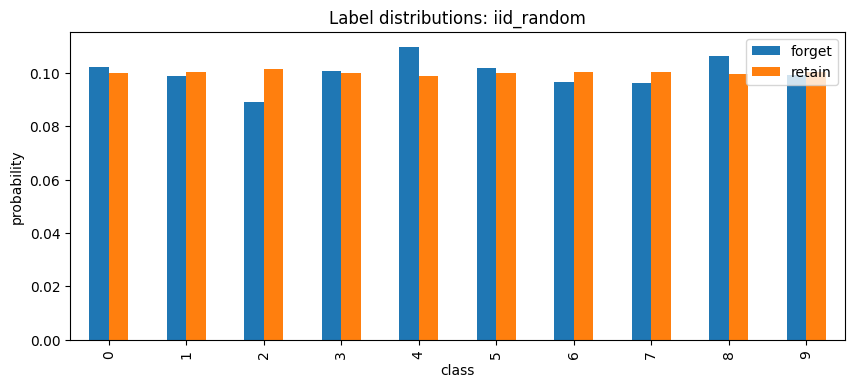

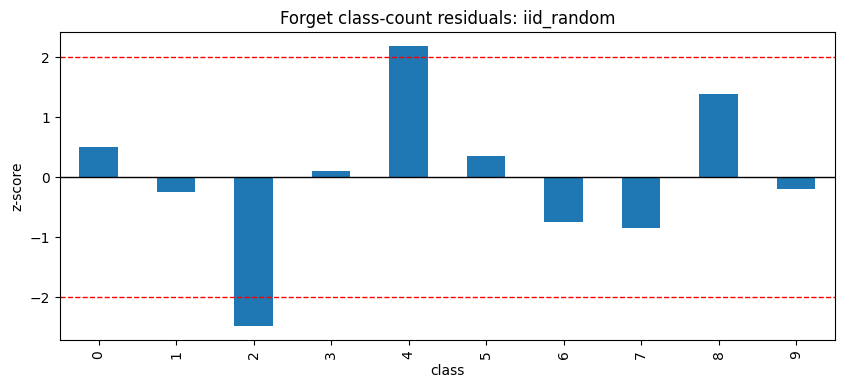

In [16]:
forget_targets = get_targets(forget_dataset)
retain_targets = get_targets(retain_dataset)
label_metrics = label_divergence(forget_targets, retain_targets, CONFIG["num_classes"])
residual_df = class_count_residuals(forget_targets, retain_targets, CONFIG["num_classes"])
perm_df = permutation_baseline(
    forget_targets,
    retain_targets,
    CONFIG["num_classes"],
    trials=CONFIG["permutation_trials"],
    seed=CONFIG["seed"],
)

label_summary = pd.DataFrame([
    {
        "forget_mode": selection["forget_mode"],
        "forget_size": len(forget_targets),
        "retain_size": len(retain_targets),
        "tv": label_metrics["tv"],
        "jsd_bits": label_metrics["jsd_bits"],
    }
])
display(label_summary)
display(perm_df)
display(residual_df)

hist_df = pd.DataFrame({
    "class": np.arange(CONFIG["num_classes"]),
    "forget": label_metrics["forget_distribution"],
    "retain": label_metrics["retain_distribution"],
})
display(hist_df)

ax = hist_df.plot(x="class", y=["forget", "retain"], kind="bar", figsize=(10, 4))
ax.set_ylabel("probability")
ax.set_title(f"Label distributions: {selection['forget_mode']}")
plt.show()

ax = residual_df.plot(x="class", y="forget_z", kind="bar", figsize=(10, 4), legend=False)
ax.axhline(0.0, color="black", linewidth=1)
ax.axhline(2.0, color="red", linestyle="--", linewidth=1)
ax.axhline(-2.0, color="red", linestyle="--", linewidth=1)
ax.set_ylabel("z-score")
ax.set_title(f"Forget class-count residuals: {selection['forget_mode']}")
plt.show()

In [17]:
feature_metrics = None

if CONFIG["checkpoint"]:
    feature_metrics = compute_feature_metrics(
        model,
        forget_loader,
        retain_loader,
        CONFIG,
        device,
    )
    feature_metrics["forget_mode"] = selection["forget_mode"]
    display(pd.DataFrame([feature_metrics]))
else:
    print("CONFIG['checkpoint'] is empty, so feature-space metrics were skipped.")

,forget_feature_samples,retain_feature_samples,feature_dim,mean_l2,linear_mmd2,frechet_distance,domain_auc,forget_mode
0,4000,4000,512,0.116618,0.0136,0.098085,0.504251,iid_random


setup random seed = 1
Dataset information: CIFAR-10	 45000 images for training 	 5000 images for validation	
10000 images for testing	 no normalize applied in data_transform
Data augmentation = randomcrop(32,4) + randomhorizontalflip
Files already downloaded and verified
Files already downloaded and verified
Dataset information: CIFAR-10	 45000 images for training 	 5000 images for validation	
10000 images for testing	 no normalize applied in data_transform
Data augmentation = randomcrop(32,4) + randomhorizontalflip
Files already downloaded and verified
Files already downloaded and verified
setup random seed = 1
The normalize layer is contained in the network
setup random seed = 1
ResNet(
  (normalize): NormalizeByChannelMeanStd(mean=tensor([0.4914, 0.4822, 0.4465]), std=tensor([0.2470, 0.2435, 0.2616]))
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu

,forget_mode,description,forget_size,retain_size,label_tv,label_jsd_bits,forget_feature_samples,retain_feature_samples,feature_dim,mean_l2,linear_mmd2,frechet_distance,domain_auc
0,iid_random,"IID random forget, n=4500 out of 45000",4500,40500,0.022469,0.000656,4000,4000,512,0.116618,0.013600,0.098085,0.504251
1,class,"class-wise forget, class=0",4500,40500,1.000000,1.000000,4000,4000,512,5.594717,31.300853,49.690752,1.000000


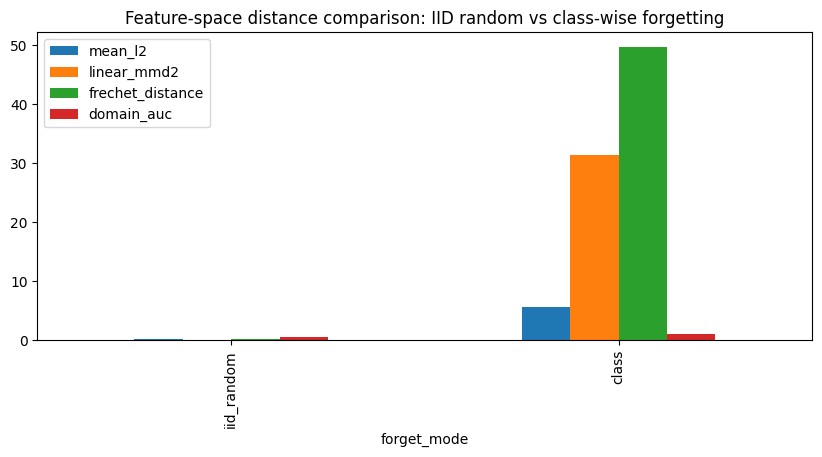

In [18]:
comparison_rows = []

if not CONFIG["checkpoint"]:
    print("CONFIG['checkpoint'] is empty, so mode comparison was skipped.")
else:
    for mode in CONFIG["comparison_modes"]:
        bundle_mode = build_split_bundle(CONFIG, forget_mode=mode)
        forget_targets_mode = get_targets(bundle_mode["forget_dataset"])
        retain_targets_mode = get_targets(bundle_mode["retain_dataset"])
        label_mode = label_divergence(forget_targets_mode, retain_targets_mode, CONFIG["num_classes"])
        feature_mode = compute_feature_metrics(
            bundle_mode["model"],
            bundle_mode["forget_loader"],
            bundle_mode["retain_loader"],
            CONFIG,
            bundle_mode["device"],
        )

        comparison_rows.append({
            "forget_mode": mode,
            "description": bundle_mode["selection"]["description"],
            "forget_size": len(bundle_mode["forget_dataset"]),
            "retain_size": len(bundle_mode["retain_dataset"]),
            "label_tv": label_mode["tv"],
            "label_jsd_bits": label_mode["jsd_bits"],
            **feature_mode,
        })

    comparison_df = pd.DataFrame(comparison_rows)
    display(comparison_df)

    metric_cols = ["mean_l2", "linear_mmd2", "frechet_distance", "domain_auc"]
    ax = comparison_df.set_index("forget_mode")[metric_cols].plot(kind="bar", figsize=(10, 4))
    ax.set_title("Feature-space distance comparison: IID random vs class-wise forgetting")
    plt.show()

## Reading the comparison

- `label_tv` and `label_jsd_bits` mainly reflect label-composition shift.
- In class-wise forgetting, those label distances should be much larger by construction.
- In IID random forgetting, label distances should stay small if the forget set is a normal sample from the full training distribution.
- `mean_l2`, `linear_mmd2`, `frechet_distance`, and `domain_auc` compare the two subsets in model feature space.
- If class-wise forgetting produces much larger feature distances than IID random forgetting, that means the forget subset is not only label-shifted but also much easier to distinguish in representation space.
